# Importância das Features — TREC 2007

Análise das features (termos) mais relevantes para a classificação de spam e ham, segundo cada um dos quatro modelos treinados com TF-IDF (max_features=10 000, ngram_range=(1, 2)).

Objetivos:
- Identificar os termos mais indicativos de **spam** e de **ham** para cada modelo;
- Comparar quais features são consideradas importantes por múltiplos modelos;
- Visualizar um heatmap normalizado das pontuações de importância entre os modelos.

In [ ]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# ── Caminhos ──────────────────────────────────────────────────────────
BASE = Path().resolve().parents[1]  # raiz do projeto (notebooks/conclusions/ → notebooks/ → raiz)
MODEL_DIR = BASE / "models" / "trec"
FIG_DIR = BASE / "figures" / "conclusions"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Carregar modelos e vetorizador ────────────────────────────────────
nb  = joblib.load(MODEL_DIR / "model_naive_bayes.pkl")
svm = joblib.load(MODEL_DIR / "model_svm.pkl")
rf  = joblib.load(MODEL_DIR / "model_random_forest.pkl")
lr  = joblib.load(MODEL_DIR / "model_regressao_logística.pkl")
tfidf = joblib.load(MODEL_DIR / "tfidf.pkl")

feature_names = np.array(tfidf.get_feature_names_out())
print(f"Total de features: {len(feature_names)}")

# ── Paleta de cores ───────────────────────────────────────────────────
NAVY   = "#1C2B4A"
TEAL   = "#0891B2"
RED    = "#DC2626"
ORANGE = "#F59E0B"
GRAY   = "#64748B"

MODEL_COLORS = {
    "Naive Bayes": TEAL,
    "SVM": NAVY,
    "Random Forest": ORANGE,
    "Regressão Logística": RED,
}

print("Modelos e vetorizador carregados com sucesso.")

In [2]:
# ── Extração das importâncias ─────────────────────────────────────────
# Naive Bayes: diferença do log-probabilidade entre classe 1 (spam) e classe 0 (ham)
nb_importance = nb.feature_log_prob_[1] - nb.feature_log_prob_[0]

# SVM (LinearSVC): coeficientes — valores positivos indicam spam
svm_importance = svm.coef_[0]

# Random Forest: importância baseada em impureza (não distingue direção)
rf_importance = rf.feature_importances_

# Regressão Logística: coeficientes — valores positivos indicam spam
lr_importance = lr.coef_[0]

importances = {
    "Naive Bayes": nb_importance,
    "SVM": svm_importance,
    "Random Forest": rf_importance,
    "Regressão Logística": lr_importance,
}

for nome, imp in importances.items():
    print(f"{nome:25s} | min: {imp.min():.4f} | max: {imp.max():.4f} | shape: {imp.shape}")

Naive Bayes               | min: -6.3645 | max: 5.1109 | shape: (10000,)
SVM                       | min: -5.8897 | max: 5.5758 | shape: (10000,)
Random Forest             | min: 0.0000 | max: 0.0422 | shape: (10000,)
Regressão Logística       | min: -12.7959 | max: 7.2900 | shape: (10000,)


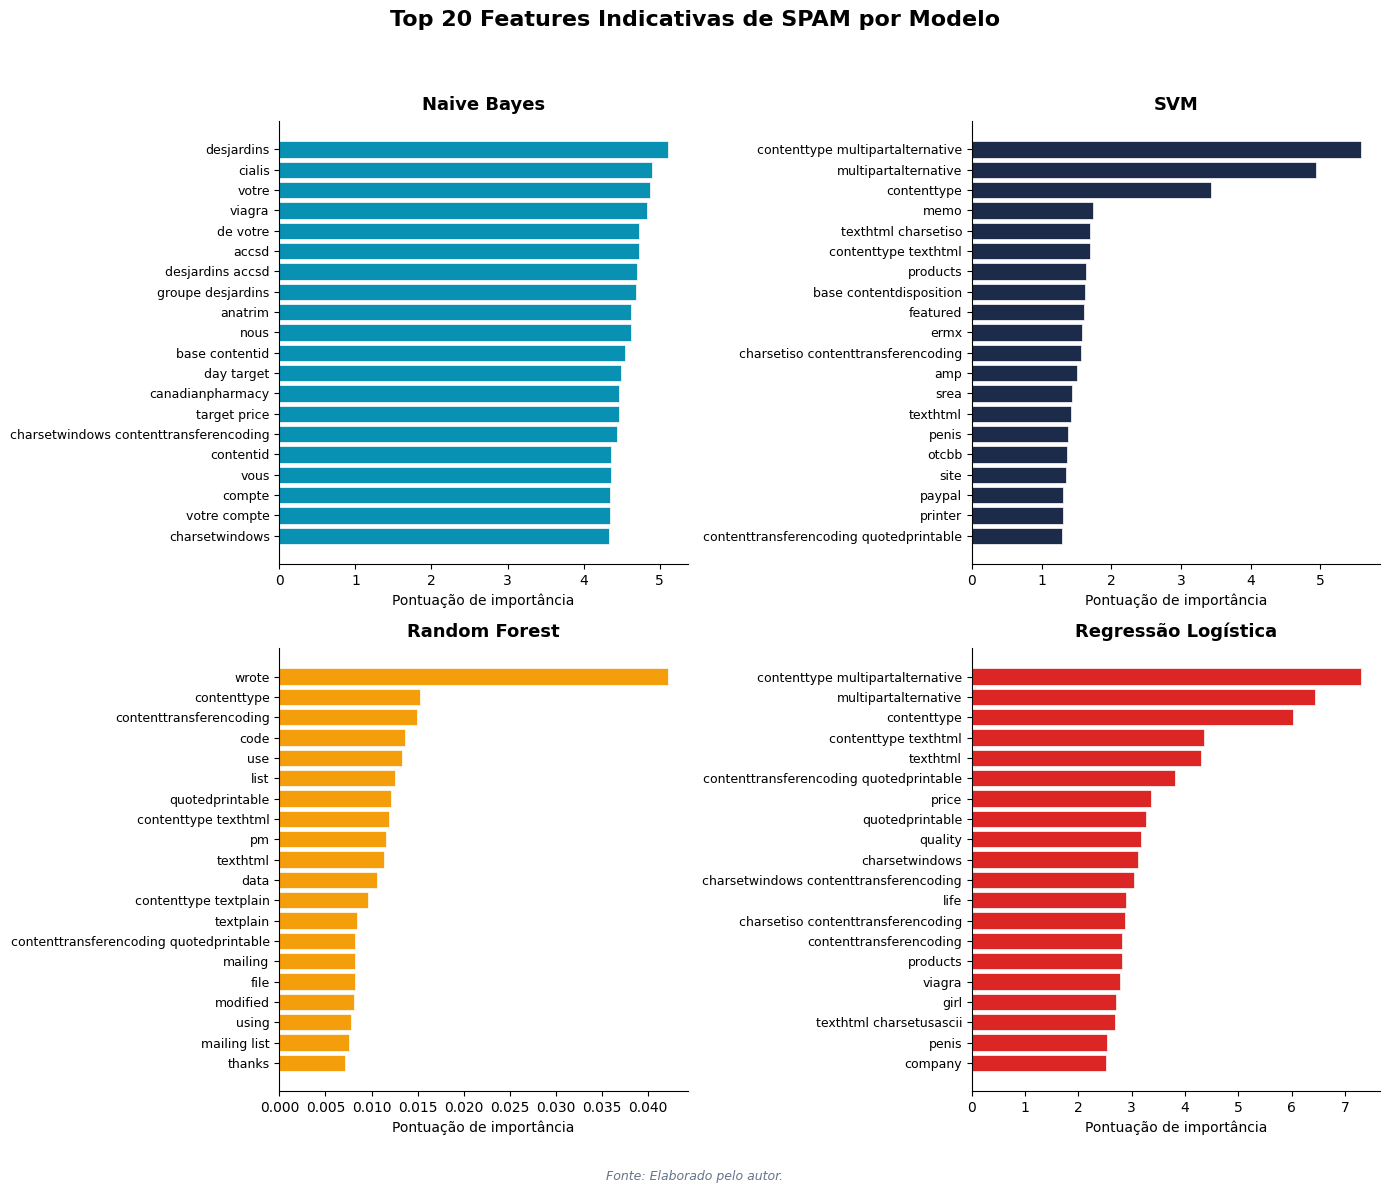

In [3]:
# ── Top 20 features indicativas de SPAM por modelo ───────────────────
def top_features(importance, feature_names, n=20, direction="positive"):
    """Retorna as top-n features em ordem decrescente de importância.

    direction='positive' → maiores valores (indicativas de spam).
    direction='negative' → menores valores (indicativas de ham).
    direction='absolute' → maiores em valor absoluto (RF).
    """
    if direction == "positive":
        idx = np.argsort(importance)[-n:][::-1]
    elif direction == "negative":
        idx = np.argsort(importance)[:n]
    else:  # absolute
        idx = np.argsort(np.abs(importance))[-n:][::-1]
    return feature_names[idx], importance[idx]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Top 20 Features Indicativas de SPAM por Modelo", fontsize=16, fontweight="bold", y=0.98)

model_list = ["Naive Bayes", "SVM", "Random Forest", "Regressão Logística"]

for ax, model_name in zip(axes.ravel(), model_list):
    imp = importances[model_name]
    names, scores = top_features(imp, feature_names, n=20, direction="positive")
    color = MODEL_COLORS[model_name]

    # Inverter para que o mais importante fique no topo
    ax.barh(range(len(names)), scores[::-1], color=color, edgecolor="white", linewidth=0.5)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names[::-1], fontsize=9)
    ax.set_title(model_name, fontsize=13, fontweight="bold", pad=8)
    ax.set_xlabel("Pontuação de importância", fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.text(0.5, 0.005, "Fonte: Elaborado pelo autor.", ha="center", fontsize=9, style="italic", color=GRAY)
plt.show()

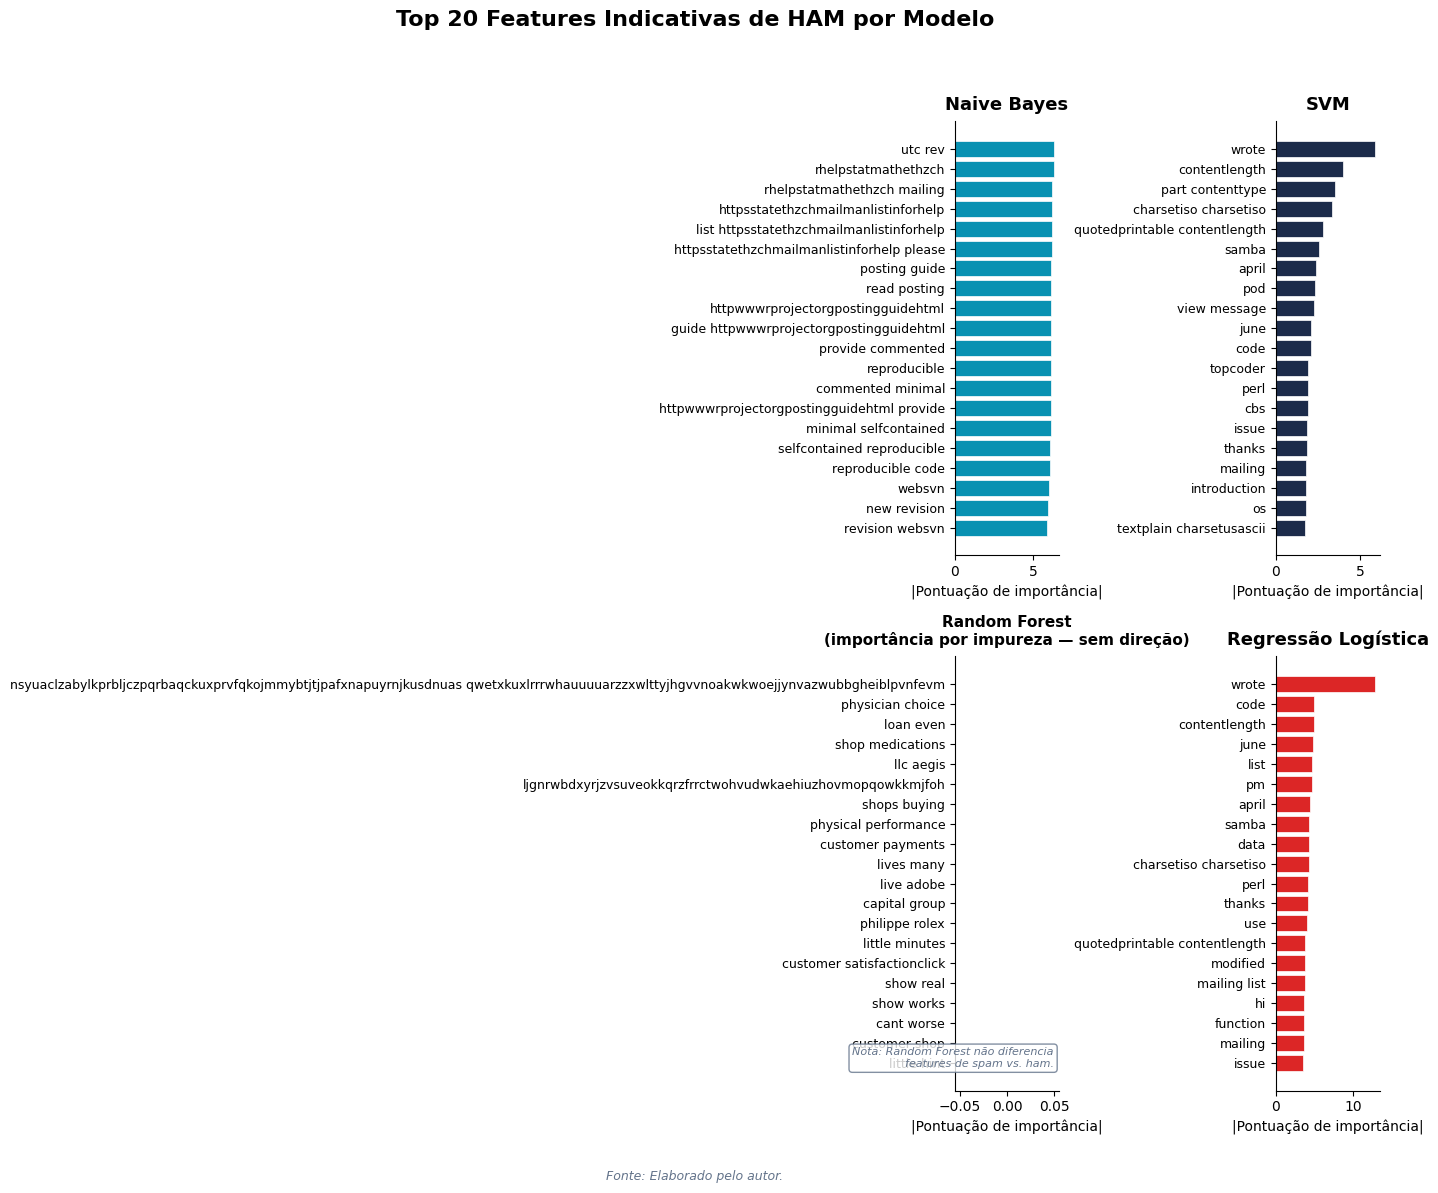

In [4]:
# ── Top 20 features indicativas de HAM por modelo ────────────────────
# Para modelos lineares (NB, SVM, LR): coeficientes mais negativos indicam HAM.
# Para Random Forest: a importância não distingue direção — exibimos nota explicativa.

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Top 20 Features Indicativas de HAM por Modelo", fontsize=16, fontweight="bold", y=0.98)

for ax, model_name in zip(axes.ravel(), model_list):
    imp = importances[model_name]
    color = MODEL_COLORS[model_name]

    if model_name == "Random Forest":
        # RF não distingue direção — mostrar nota e exibir as de menor importância
        names, scores = top_features(imp, feature_names, n=20, direction="negative")
        ax.barh(range(len(names)), scores[::-1], color=color, edgecolor="white", linewidth=0.5)
        ax.set_yticks(range(len(names)))
        ax.set_yticklabels(names[::-1], fontsize=9)
        ax.set_title(f"{model_name}\n(importância por impureza — sem direção)", fontsize=11, fontweight="bold", pad=8)
        ax.annotate(
            "Nota: Random Forest não diferencia\nfeatures de spam vs. ham.",
            xy=(0.95, 0.05), xycoords="axes fraction", fontsize=8,
            ha="right", va="bottom", style="italic", color=GRAY,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=GRAY, alpha=0.8),
        )
    else:
        # Modelos lineares: coeficientes negativos → HAM
        names, scores = top_features(imp, feature_names, n=20, direction="negative")
        abs_scores = np.abs(scores)
        ax.barh(range(len(names)), abs_scores[::-1], color=color, edgecolor="white", linewidth=0.5)
        ax.set_yticks(range(len(names)))
        ax.set_yticklabels(names[::-1], fontsize=9)
        ax.set_title(model_name, fontsize=13, fontweight="bold", pad=8)

    ax.set_xlabel("|Pontuação de importância|", fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.text(0.5, 0.005, "Fonte: Elaborado pelo autor.", ha="center", fontsize=9, style="italic", color=GRAY)
plt.show()

In [5]:
# ── Features comuns entre modelos (Top 20 SPAM) ──────────────────────
from collections import Counter

top20_spam = {}
for model_name in model_list:
    imp = importances[model_name]
    names, _ = top_features(imp, feature_names, n=20, direction="positive")
    top20_spam[model_name] = set(names)

# Contar em quantos modelos cada feature aparece
all_features_flat = [f for s in top20_spam.values() for f in s]
feat_counts = Counter(all_features_flat)

# Filtrar features que aparecem em pelo menos 2 modelos
common = {f: c for f, c in feat_counts.items() if c >= 2}
common_sorted = sorted(common.items(), key=lambda x: -x[1])

# Montar tabela
rows = []
for feat, count in common_sorted:
    modelos = [m for m in model_list if feat in top20_spam[m]]
    rows.append({
        "Feature": feat,
        "Nº de Modelos": count,
        "Modelos": ", ".join(modelos),
    })

df_common = pd.DataFrame(rows)
print(f"Features SPAM presentes no top-20 de 2 ou mais modelos: {len(df_common)}")
df_common.style.set_caption("Features indicativas de SPAM comuns entre modelos").hide(axis="index")

Features SPAM presentes no top-20 de 2 ou mais modelos: 14


Feature,Nº de Modelos,Modelos
contenttype,3,"SVM, Random Forest, Regressão Logística"
contenttype texthtml,3,"SVM, Random Forest, Regressão Logística"
texthtml,3,"SVM, Random Forest, Regressão Logística"
contenttransferencoding quotedprintable,3,"SVM, Random Forest, Regressão Logística"
charsetwindows contenttransferencoding,2,"Naive Bayes, Regressão Logística"
viagra,2,"Naive Bayes, Regressão Logística"
charsetwindows,2,"Naive Bayes, Regressão Logística"
penis,2,"SVM, Regressão Logística"
products,2,"SVM, Regressão Logística"
multipartalternative,2,"SVM, Regressão Logística"


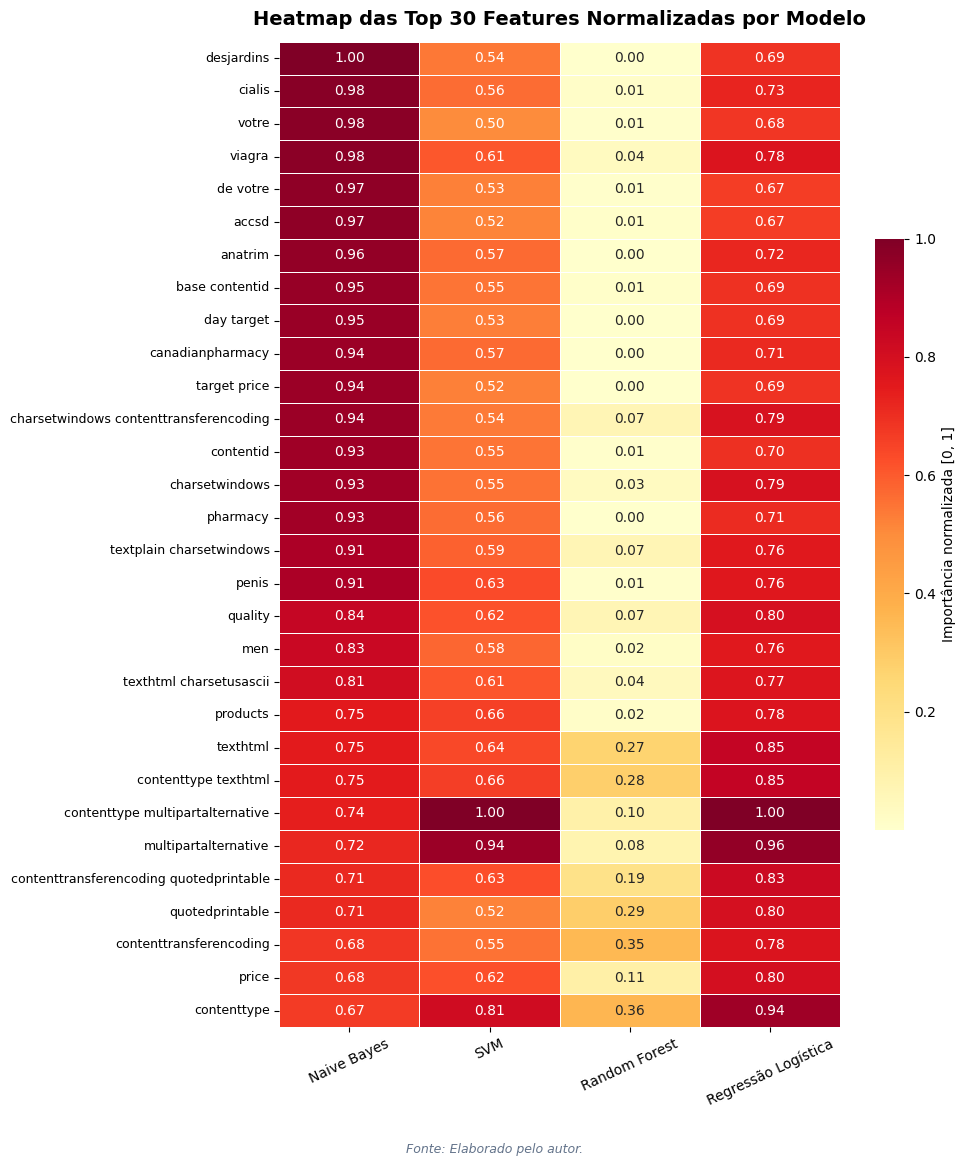

In [6]:
# ── Heatmap: Top 30 features normalizadas entre modelos ───────────────
from sklearn.preprocessing import MinMaxScaler

# Selecionar as top-30 features por valor absoluto em cada modelo e unir
top_n_heat = 30
union_features = set()
for model_name in model_list:
    imp = importances[model_name]
    names, _ = top_features(imp, feature_names, n=top_n_heat, direction="absolute" if model_name == "Random Forest" else "positive")
    union_features.update(names)

# Reduzir ao top-30 por soma de ranks normalizados
scaler = MinMaxScaler()
norm_dict = {}
for model_name in model_list:
    imp = importances[model_name]
    norm_dict[model_name] = scaler.fit_transform(imp.reshape(-1, 1)).ravel()

# Montar DataFrame com todas as features da união, depois selecionar top 30 pelo score médio
union_list = sorted(union_features)
idx_map = {f: i for i, f in enumerate(feature_names)}
heat_data = pd.DataFrame(
    {m: [norm_dict[m][idx_map[f]] for f in union_list] for m in model_list},
    index=union_list,
)
heat_data["media"] = heat_data.mean(axis=1)
heat_data = heat_data.nlargest(top_n_heat, "media").drop(columns="media")
heat_data = heat_data.sort_values(by=list(heat_data.columns), ascending=False)

# Plotar heatmap
fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(
    heat_data,
    annot=True, fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Importância normalizada [0, 1]", "shrink": 0.6},
    ax=ax,
)
ax.set_title("Heatmap das Top 30 Features Normalizadas por Modelo", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=9)
ax.tick_params(axis="x", labelsize=10, rotation=25)

fig.tight_layout(rect=[0, 0.03, 1, 0.97])
fig.text(0.5, 0.005, "Fonte: Elaborado pelo autor.", ha="center", fontsize=9, style="italic", color=GRAY)
plt.show()

In [7]:
# ── Salvar todas as figuras ───────────────────────────────────────────

# 1) Top 20 SPAM
fig_spam, axes_spam = plt.subplots(2, 2, figsize=(14, 12))
fig_spam.suptitle("Top 20 Features Indicativas de SPAM por Modelo", fontsize=16, fontweight="bold", y=0.98)

for ax, model_name in zip(axes_spam.ravel(), model_list):
    imp = importances[model_name]
    names, scores = top_features(imp, feature_names, n=20, direction="positive")
    color = MODEL_COLORS[model_name]
    ax.barh(range(len(names)), scores[::-1], color=color, edgecolor="white", linewidth=0.5)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names[::-1], fontsize=9)
    ax.set_title(model_name, fontsize=13, fontweight="bold", pad=8)
    ax.set_xlabel("Pontuação de importância", fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig_spam.tight_layout(rect=[0, 0.03, 1, 0.95])
fig_spam.text(0.5, 0.005, "Fonte: Elaborado pelo autor.", ha="center", fontsize=9, style="italic", color=GRAY)
fig_spam.savefig(FIG_DIR / "feature_importance_spam_top20.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.close(fig_spam)

# 2) Top 20 HAM
fig_ham, axes_ham = plt.subplots(2, 2, figsize=(14, 12))
fig_ham.suptitle("Top 20 Features Indicativas de HAM por Modelo", fontsize=16, fontweight="bold", y=0.98)

for ax, model_name in zip(axes_ham.ravel(), model_list):
    imp = importances[model_name]
    color = MODEL_COLORS[model_name]

    if model_name == "Random Forest":
        names, scores = top_features(imp, feature_names, n=20, direction="negative")
        ax.barh(range(len(names)), scores[::-1], color=color, edgecolor="white", linewidth=0.5)
        ax.set_yticks(range(len(names)))
        ax.set_yticklabels(names[::-1], fontsize=9)
        ax.set_title(f"{model_name}\n(importância por impureza — sem direção)", fontsize=11, fontweight="bold", pad=8)
        ax.annotate(
            "Nota: Random Forest não diferencia\nfeatures de spam vs. ham.",
            xy=(0.95, 0.05), xycoords="axes fraction", fontsize=8,
            ha="right", va="bottom", style="italic", color=GRAY,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=GRAY, alpha=0.8),
        )
    else:
        names, scores = top_features(imp, feature_names, n=20, direction="negative")
        abs_scores = np.abs(scores)
        ax.barh(range(len(names)), abs_scores[::-1], color=color, edgecolor="white", linewidth=0.5)
        ax.set_yticks(range(len(names)))
        ax.set_yticklabels(names[::-1], fontsize=9)
        ax.set_title(model_name, fontsize=13, fontweight="bold", pad=8)

    ax.set_xlabel("|Pontuação de importância|", fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig_ham.tight_layout(rect=[0, 0.03, 1, 0.95])
fig_ham.text(0.5, 0.005, "Fonte: Elaborado pelo autor.", ha="center", fontsize=9, style="italic", color=GRAY)
fig_ham.savefig(FIG_DIR / "feature_importance_ham_top20.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.close(fig_ham)

# 3) Heatmap
fig_heat, ax_heat = plt.subplots(figsize=(10, 12))
sns.heatmap(
    heat_data,
    annot=True, fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Importância normalizada [0, 1]", "shrink": 0.6},
    ax=ax_heat,
)
ax_heat.set_title("Heatmap das Top 30 Features Normalizadas por Modelo", fontsize=14, fontweight="bold", pad=12)
ax_heat.set_xlabel("")
ax_heat.set_ylabel("")
ax_heat.tick_params(axis="y", labelsize=9)
ax_heat.tick_params(axis="x", labelsize=10, rotation=25)

fig_heat.tight_layout(rect=[0, 0.03, 1, 0.97])
fig_heat.text(0.5, 0.005, "Fonte: Elaborado pelo autor.", ha="center", fontsize=9, style="italic", color=GRAY)
fig_heat.savefig(FIG_DIR / "feature_importance_heatmap.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.close(fig_heat)

print("Figuras salvas em:")
for f in sorted(FIG_DIR.glob("feature_importance_*.png")):
    print(f"  {f}")

Figuras salvas em:
  /home/edson-luiz/Projetos/TCC/figures/conclusions/feature_importance_ham_top20.png
  /home/edson-luiz/Projetos/TCC/figures/conclusions/feature_importance_heatmap.png
  /home/edson-luiz/Projetos/TCC/figures/conclusions/feature_importance_spam_top20.png
